# Finding the top and bottom of brain tissue in 3D image stacks

This notebook walks through how we automatically find where the brain
tissue **starts** (the top surface, called the *pia*) and where it
**ends** (the bottom surface) inside a 3D microscope image stack.

We have two kinds of images per brain:

1. A large *anatomy* stack (called **HCR**) — we want both the top and
   the bottom of the tissue here.
2. A smaller *live-function* stack (called **CZ**) — we only want the
   top.  For these, the experimenter set up the microscope so that the
   pia sits **about 50 micrometres (µm) from the first slice**.  That
   single number is a strong hint we can use.

The example subject used for step-by-step illustrations is
`767022`; the final section shows the result for every subject.

Everything runs in a Python kernel launched from this session
directory.  The imports below are reused by every cell.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("/root/capsule")
SESSION = ROOT / "code" / "sessions" / "03c_onset_features"
sys.path.insert(0, str(ROOT / "code" / "dev_code"))
sys.path.insert(0, str(SESSION / "iterations"))

from benchmark_analysis import load_hcr_combined
from benchmark_data_loader import load_subject
from iter07_compute import (
    col_detect_transition, eval_polysurf, fit_polysurf,
    sampling_grid, EPS, PATCH_W, POLY_DEGREE, HUBER_K,
    SMOOTH_Z_UM, SUSTAIN_Z_UM, TRANS_FRAC, THR_FLOOR,
)
from iter08_cz_prior import (
    CZ_TARGET_Z_UM, TRANS_FRAC_BANK, GATE_UM, CZ_THR_FLOOR,
    load_cz_volume, select_trans_frac, fit_gated_surface,
    _patch_log_columns as cz_patch_cols,
)
from iter08_hcr_bottom import (
    detect_top_transitions, detect_bottom_transitions, mad_gate,
)
EXAMPLE = '767022'


## 1. What the data looks like

Each image stack is a 3D array of brightness values.  You can think of
it as a stack of grayscale photographs, one on top of the next, where
*going down the stack* corresponds to going deeper into the brain.

The cell below loads the two stacks for our example subject and shows
one vertical cross-section (a slice that cuts through depth rather
than across it).  Bright means *tissue*; dark means *outside tissue*
(above the brain, below the brain, or at the sides).

/opt/conda/lib/python3.11/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


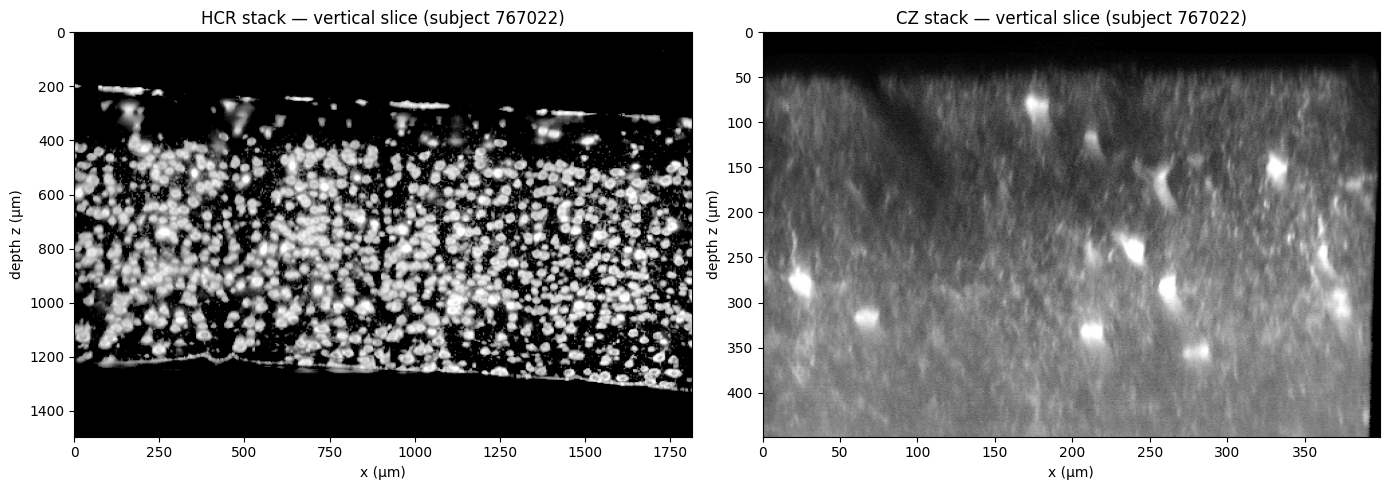

In [2]:
s = load_subject(EXAMPLE)
hcr, hcr_xy, hcr_z, _ = load_hcr_combined(s, level=4)
cz = load_cz_volume(s)
cz_z, cz_xy = s.cz_z_um, s.cz_xy_um

def vslice(vol, iy, xy, z_um):
    img = np.log(vol[:, iy, :] + EPS)
    xs = np.arange(vol.shape[2]) * xy
    zs = np.arange(vol.shape[0]) * z_um
    return img, xs, zs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

img, xs, zs = vslice(hcr, hcr.shape[1]//2, hcr_xy, hcr_z)
axes[0].imshow(img, cmap='gray', aspect='auto', origin='upper',
               extent=[xs[0], xs[-1], zs[-1], zs[0]],
               vmin=np.percentile(img,5), vmax=np.percentile(img,99.5))
axes[0].set_title(f'HCR stack — vertical slice (subject {EXAMPLE})')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('depth z (µm)')

img, xs, zs = vslice(cz, cz.shape[1]//2, cz_xy, cz_z)
axes[1].imshow(img, cmap='gray', aspect='auto', origin='upper',
               extent=[xs[0], xs[-1], zs[-1], zs[0]],
               vmin=np.percentile(img,5), vmax=np.percentile(img,99.5))
axes[1].set_title(f'CZ stack — vertical slice (subject {EXAMPLE})')
axes[1].set_xlabel('x (µm)'); axes[1].set_ylabel('depth z (µm)')
plt.tight_layout(); plt.show()


Notice two things:

* The HCR stack has a dark band above the tissue **and** below it —
  we want both edges of the bright block.
* The CZ stack has a dark band above and gradually darker tissue
  below; we only want the top edge here.

The goal is to trace, across every pair of (x, y) positions, the z
value where the dark outside becomes the bright inside.

## 2. One depth profile at a time

Pick one (x, y) location and plot the brightness as you go deeper.
We'll call this the **depth profile** for that location.  The edge we
want to find is where the profile rises from "dark" to "bright".

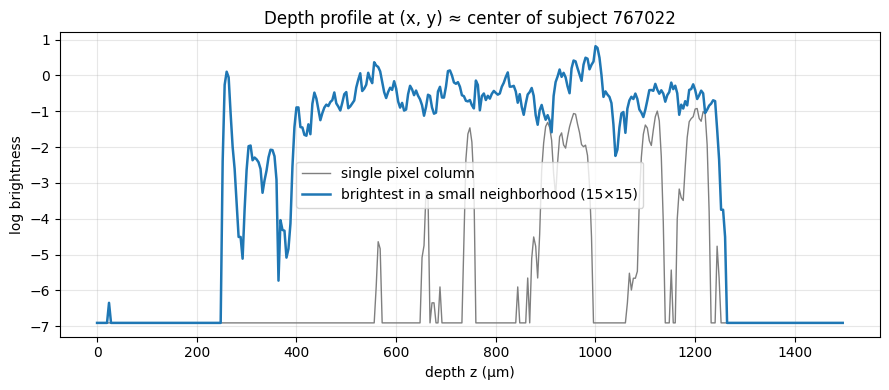

In [3]:
iy = hcr.shape[1]//2
ix = hcr.shape[2]//2

single = hcr[:, iy, ix]
patch  = hcr[:, max(0, iy-PATCH_W):iy+PATCH_W+1,
               max(0, ix-PATCH_W):ix+PATCH_W+1].max(axis=(1,2))
zs = np.arange(hcr.shape[0]) * hcr_z

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(zs, np.log(single + EPS), color='tab:gray', lw=1.0,
        label='single pixel column')
ax.plot(zs, np.log(patch  + EPS), color='tab:blue', lw=1.8,
        label='brightest in a small neighborhood (15×15)')
ax.set_xlabel('depth z (µm)'); ax.set_ylabel('log brightness')
ax.set_title(f'Depth profile at (x, y) ≈ center of subject {EXAMPLE}')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


The gray line is the brightness of a single pixel at
each depth.  It's noisy: one cell can turn the whole profile on or
off.  The blue line is the **brightest value in a small
neighborhood** of 15 × 15 pixels (about 60 µm wide).  Taking the
brightest keeps sparse single cells visible, and it's much more
stable.  We'll use the blue profile from here on.

## 3. Smoothing and choosing a brightness cutoff

Even the neighborhood profile wiggles.  We smooth it gently in depth
(over about 5 µm) so that the edge we detect is the real
tissue-vs-outside boundary, not a single bright pixel.

Then we need to pick a **brightness cutoff** — one value on the
vertical axis such that "above cutoff" means *inside tissue* and
"below cutoff" means *outside*.  A fixed number doesn't work across
different images, so we pick the cutoff *from the profile itself*:
halfway between the profile's 10th-percentile (its dark floor) and
its 90th-percentile (its bright ceiling).  This is automatic and
scales with each column's own dark/bright levels.

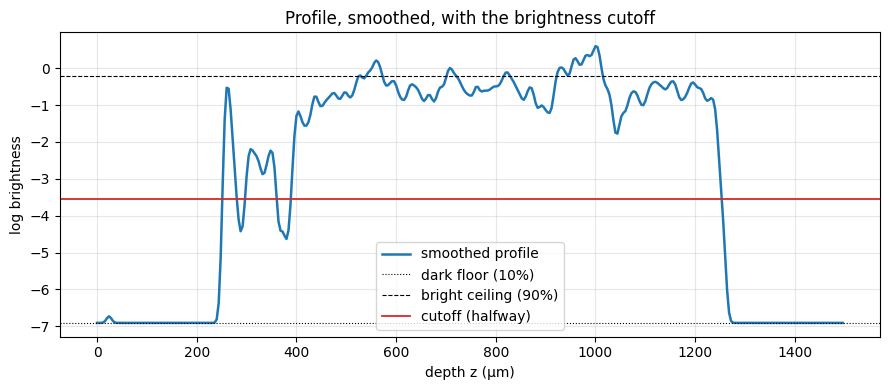

dark floor  = -6.91
bright ceil = -0.20
cutoff      = -3.55


In [4]:
from scipy.ndimage import gaussian_filter1d

sigma = max(1.0, SMOOTH_Z_UM / hcr_z)
smooth = gaussian_filter1d(np.log(patch + EPS), sigma=sigma)
p10, p90 = np.percentile(smooth, [10, 90])
thr = max(THR_FLOOR, p10 + TRANS_FRAC * (p90 - p10))

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(zs, smooth, color='tab:blue', lw=1.8, label='smoothed profile')
ax.axhline(p10, color='k', ls=':', lw=0.8, label='dark floor (10%)')
ax.axhline(p90, color='k', ls='--', lw=0.8, label='bright ceiling (90%)')
ax.axhline(thr, color='tab:red', lw=1.3, label=f'cutoff (halfway)')
ax.set_xlabel('depth z (µm)'); ax.set_ylabel('log brightness')
ax.set_title('Profile, smoothed, with the brightness cutoff')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'dark floor  = {p10:.2f}')
print(f'bright ceil = {p90:.2f}')
print(f'cutoff      = {thr:.2f}')


## 4. Finding the top edge

The top edge is the first depth where the smoothed profile stays
above the cutoff for a short stretch (about 15 µm).  We require a
*sustained* crossing, not a single-sample spike, so that short
bright specks above the tissue can't fool the detector.

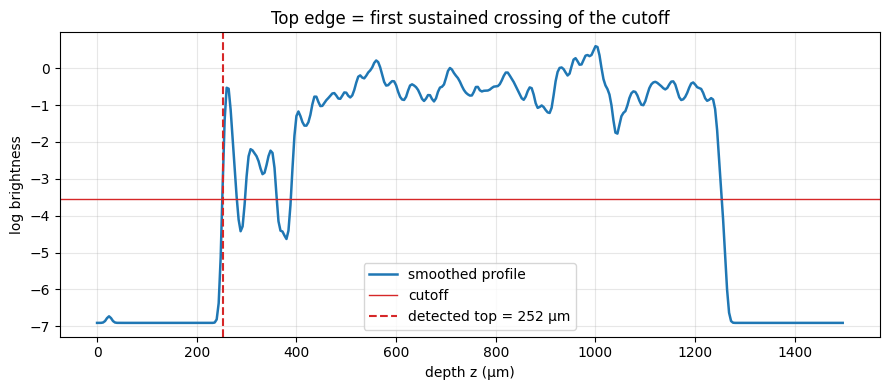

In [5]:
z_vox, _, _ = col_detect_transition(
    np.log(patch + EPS), hcr_z,
    smooth_z_um=SMOOTH_Z_UM, sustain_z_um=SUSTAIN_Z_UM,
    trans_frac=TRANS_FRAC, thr_floor=THR_FLOOR, mode='range_relative')
z_top = z_vox * hcr_z

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(zs, smooth, color='tab:blue', lw=1.8, label='smoothed profile')
ax.axhline(thr, color='tab:red', lw=1.0, label='cutoff')
ax.axvline(z_top, color='tab:red', lw=1.5, ls='--',
           label=f'detected top = {z_top:.0f} µm')
ax.set_xlabel('depth z (µm)'); ax.set_ylabel('log brightness')
ax.set_title('Top edge = first sustained crossing of the cutoff')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 5. Finding the bottom edge

For the HCR stacks the bottom is a mirror image of the top: the
profile drops back below the cutoff once the tissue ends.  We reuse
the exact same machinery — we just **read the profile in reverse**.
The first sustained crossing on the reversed profile lines up with
the last depth where we're still inside tissue.

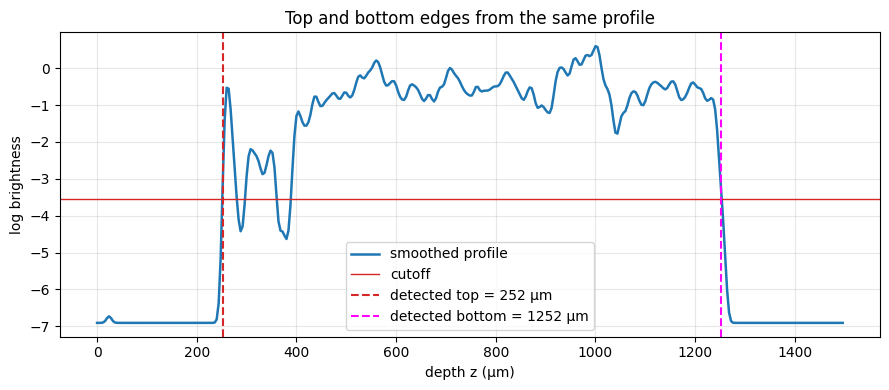

In [6]:
rev = np.log(patch + EPS)[::-1]
z_flip, _, _ = col_detect_transition(
    rev, hcr_z, smooth_z_um=SMOOTH_Z_UM, sustain_z_um=SUSTAIN_Z_UM,
    trans_frac=TRANS_FRAC, thr_floor=THR_FLOOR, mode='range_relative')
Z = len(smooth)
z_bot = (Z - 1 - z_flip) * hcr_z

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(zs, smooth, color='tab:blue', lw=1.8, label='smoothed profile')
ax.axhline(thr, color='tab:red', lw=1.0, label='cutoff')
ax.axvline(z_top, color='tab:red', lw=1.5, ls='--',
           label=f'detected top = {z_top:.0f} µm')
ax.axvline(z_bot, color='magenta', lw=1.5, ls='--',
           label=f'detected bottom = {z_bot:.0f} µm')
ax.set_xlabel('depth z (µm)'); ax.set_ylabel('log brightness')
ax.set_title('Top and bottom edges from the same profile')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 6. Repeating over a grid of (x, y) locations

Now we repeat steps 2–5 over many (x, y) locations on a 20 × 20 grid
inside the image (with a small pad from the edges).  We end up with
400 top depths and 400 bottom depths for this subject.

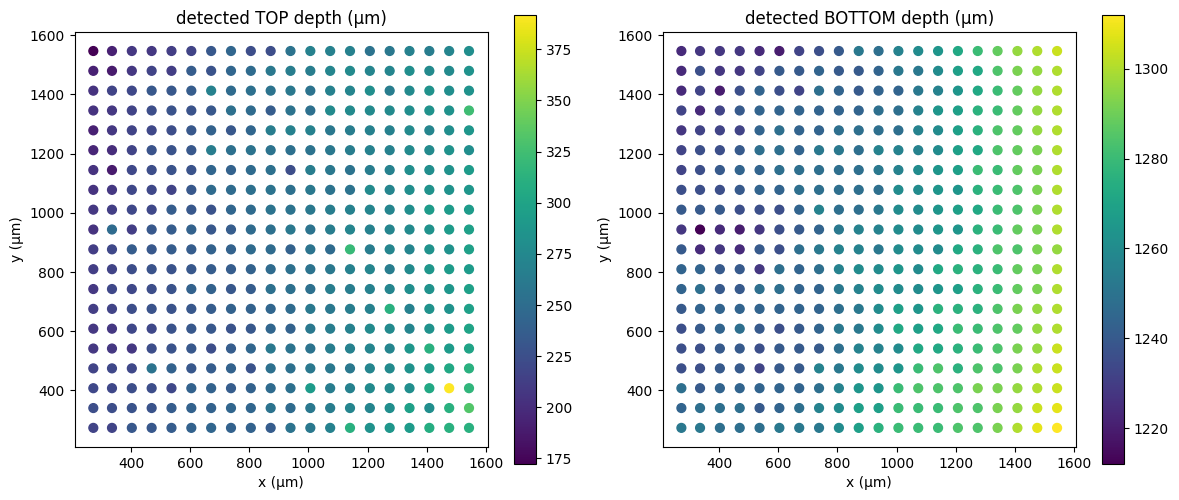

HCR top:    median 252.0 µm, range [172, 392]
HCR bottom: median 1256.0 µm, range [1212, 1312]


In [7]:
xi, yi = sampling_grid(hcr.shape, hcr_xy)
xs_um = xi * hcr_xy; ys_um = yi * hcr_xy
zs_top, _ = detect_top_transitions(hcr, hcr_z, xi, yi)
zs_bot, _ = detect_bottom_transitions(hcr, hcr_z, xi, yi)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc0 = axes[0].scatter(xs_um, ys_um, c=zs_top, cmap='viridis', s=40)
axes[0].set_aspect('equal'); axes[0].set_title('detected TOP depth (µm)')
axes[0].set_xlabel('x (µm)'); axes[0].set_ylabel('y (µm)')
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(xs_um, ys_um, c=zs_bot, cmap='viridis', s=40)
axes[1].set_aspect('equal'); axes[1].set_title('detected BOTTOM depth (µm)')
axes[1].set_xlabel('x (µm)'); axes[1].set_ylabel('y (µm)')
plt.colorbar(sc1, ax=axes[1])
plt.tight_layout(); plt.show()

print(f'HCR top:    median {np.nanmedian(zs_top):.1f} µm, '
      f'range [{np.nanmin(zs_top):.0f}, {np.nanmax(zs_top):.0f}]')
print(f'HCR bottom: median {np.nanmedian(zs_bot):.1f} µm, '
      f'range [{np.nanmin(zs_bot):.0f}, {np.nanmax(zs_bot):.0f}]')


## 7. Fitting a gently curved surface

The scatter of 400 detected depths is noisy — some columns will
contain debris, dim tissue, or an edge artefact.  We want one clean
surface z(x, y) that describes the boundary across the whole image.

We fit a **gently curved surface** (a polynomial with 6 free
parameters) to the 400 points.  Fitting is done **robustly** so that
a handful of bad columns can't bend the surface.  Robust fitting
means: fit, measure how far each point is from the fit, reduce the
weight of points that are far away, fit again, and repeat a few
times.

> **Under the hood.** The "gently curved surface" is a **bivariate
> polynomial of degree 2**:
> `z(x, y) = c₀ + c₁·x + c₂·y + c₃·x² + c₄·x·y + c₅·y²` — that's the
> six free parameters.  "Robust fitting" is **Iteratively Reweighted
> Least Squares (IRLS) with Huber weights**: each point's weight is
> `min(1, k / |residual / σ|)` with `k = 1.5` and `σ = 1.4826 · MAD`
> of the residuals; we repeat the fit for 8 iterations.  See
> `fit_polysurf` in `iter07_compute.py`.

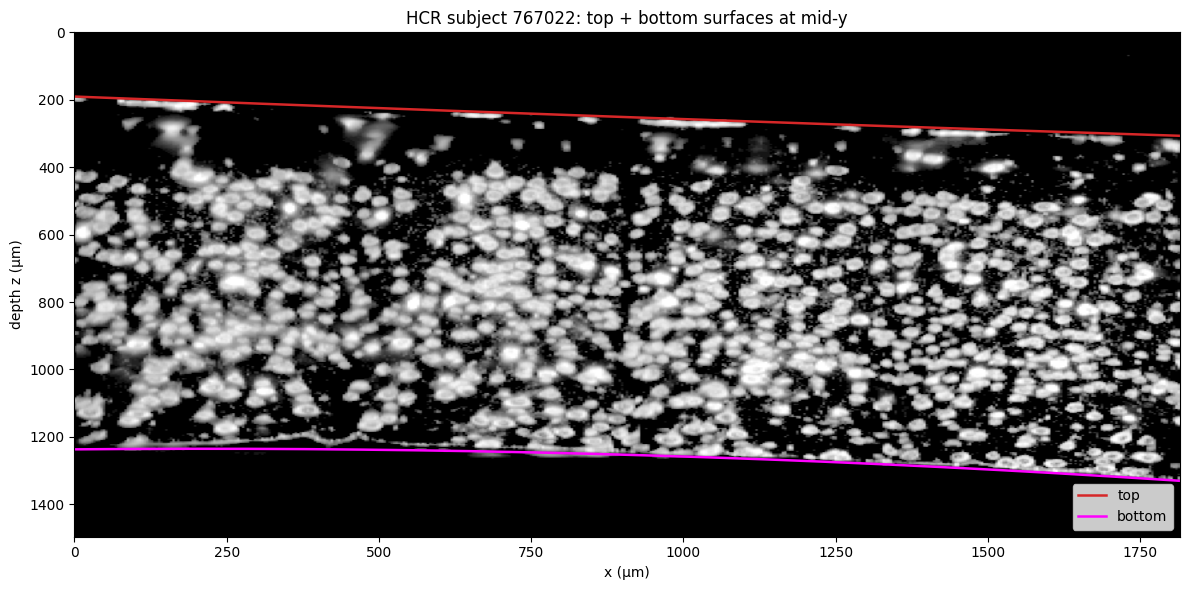

In [8]:
top_fit = fit_polysurf(xs_um, ys_um, zs_top,
                        degree=POLY_DEGREE, huber_k=HUBER_K)
gate = mad_gate(zs_bot)
bot_fit = fit_polysurf(xs_um[gate], ys_um[gate], zs_bot[gate],
                        degree=POLY_DEGREE, huber_k=HUBER_K)

iy = hcr.shape[1]//2
img, xs, zs = vslice(hcr, iy, hcr_xy, hcr_z)
x_um_full = np.arange(hcr.shape[2]) * hcr_xy
y0 = iy * hcr_xy
z_top_line = eval_polysurf(top_fit, x_um_full, np.full_like(x_um_full, y0))
z_bot_line = eval_polysurf(bot_fit, x_um_full, np.full_like(x_um_full, y0))

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(img, cmap='gray', aspect='auto', origin='upper',
          extent=[xs[0], xs[-1], zs[-1], zs[0]],
          vmin=np.percentile(img,5), vmax=np.percentile(img,99.5))
ax.plot(x_um_full, z_top_line, color='tab:red', lw=1.8, label='top')
ax.plot(x_um_full, z_bot_line, color='magenta', lw=1.8, label='bottom')
ax.set_xlabel('x (µm)'); ax.set_ylabel('depth z (µm)')
ax.set_title(f'HCR subject {EXAMPLE}: top + bottom surfaces at mid-y')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()


## 8. CZ stacks: using the 50 µm hint

The CZ stacks are trickier.  The transition from outside to inside
tissue is often a **gradual brightening** rather than a clean edge.
If we keep our cutoff at "halfway between dark and bright", on some
subjects the detector fires deep inside the tissue instead of at its
top.

Luckily we know something that the image alone doesn't tell us:
**the microscope was set up so that the pia sits roughly 50 µm from
the first slice**.  We use this hint to pick the right "sensitivity"
— that is, how far below the bright ceiling to place the cutoff.

We try seven sensitivities (2% of the range, 5%, 10%, 15%, 20%, 30%,
50%).  For each one we run the detector over the 400-column grid and
look at the median depth it produces.  We keep the sensitivity whose
median depth is closest to 50 µm.

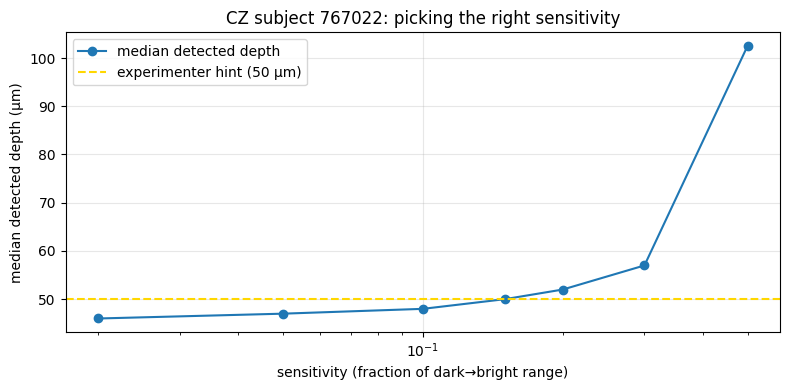

best sensitivity = 0.15  (median 50.0 µm)


In [9]:
xi_c, yi_c = sampling_grid(cz.shape, cz_xy)
xs_um_c = xi_c * cz_xy; ys_um_c = yi_c * cz_xy
log_cz = np.log(cz + EPS)
log_cols = cz_patch_cols(log_cz, xi_c, yi_c)
(sel_tf, sel_zs, _, sel_med), sweep = select_trans_frac(
    log_cols, cz_z, CZ_TARGET_Z_UM)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep.trans_frac, sweep.median_z, 'o-', color='tab:blue',
        label='median detected depth')
ax.axhline(CZ_TARGET_Z_UM, color='gold', ls='--',
           label='experimenter hint (50 µm)')
ax.set_xscale('log')
ax.set_xlabel('sensitivity (fraction of dark→bright range)')
ax.set_ylabel('median detected depth (µm)')
ax.set_title(f'CZ subject {EXAMPLE}: picking the right sensitivity')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'best sensitivity = {sel_tf}  (median {sel_med:.1f} µm)')


For subject `767022` the default sensitivity
(50% of the range) would have put the surface at about 102 µm — way
below the real pia.  Using the 50 µm hint, we automatically pick a
lower sensitivity, and the detector lands right at the top of the
tissue.

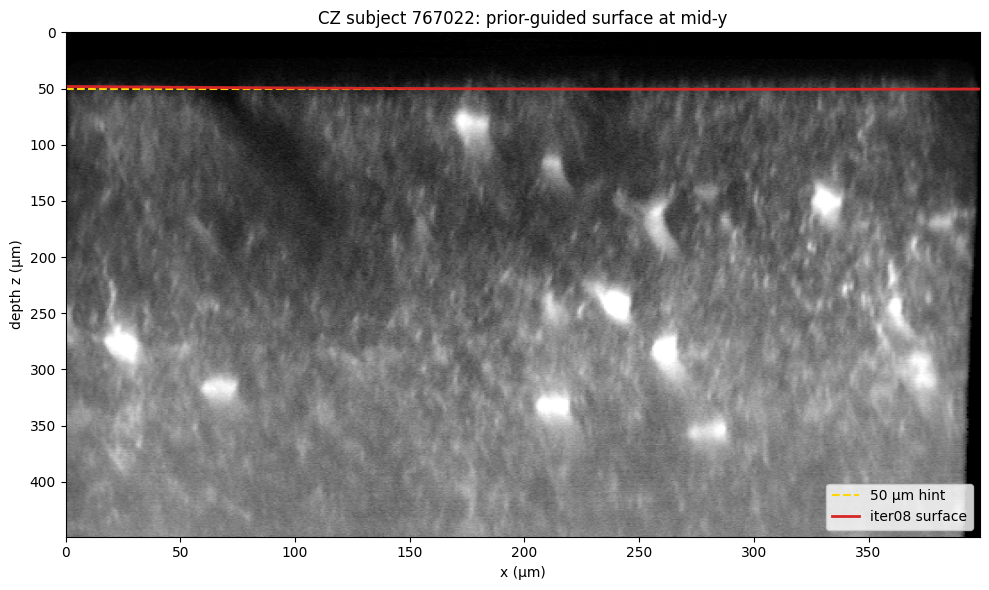

In [10]:
polyfit, _, _ = fit_gated_surface(xs_um_c, ys_um_c, sel_zs)

iy = cz.shape[1]//2
img, xs, zs = vslice(cz, iy, cz_xy, cz_z)
x_um_cz = np.arange(cz.shape[2]) * cz_xy
y0 = iy * cz_xy
z_line = eval_polysurf(polyfit, x_um_cz, np.full_like(x_um_cz, y0))

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(img, cmap='gray', aspect='auto', origin='upper',
          extent=[xs[0], xs[-1], zs[-1], zs[0]],
          vmin=np.percentile(img,5), vmax=np.percentile(img,99.5))
ax.axhline(CZ_TARGET_Z_UM, color='gold', ls='--', label='50 µm hint')
ax.plot(x_um_cz, z_line, color='tab:red', lw=2.0, label='iter08 surface')
ax.set_xlabel('x (µm)'); ax.set_ylabel('depth z (µm)')
ax.set_title(f'CZ subject {EXAMPLE}: prior-guided surface at mid-y')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()


## 9. Protocol summary (cheat-sheet)

For every (x, y) column on a 20 × 20 grid inside the image:

1. **Take the brightest value** in a 15 × 15 pixel neighborhood at
   every depth.  This gives a cleaner depth profile than a single
   pixel.
2. **Smooth** the profile gently over about 5 µm in depth so small
   wiggles don't trigger a false edge.
3. **Pick a brightness cutoff** for each profile: halfway between its
   10th-percentile (its dark floor) and its 90th-percentile (its
   bright ceiling).  Every column gets its own cutoff.
4. **Top edge**: the first depth where the smoothed profile stays
   above the cutoff for about 15 µm.
5. **Bottom edge (HCR only)**: same rule, but reading the profile in
   reverse.
6. Collect 400 top depths (and 400 bottom depths, for HCR).
7. **Fit a gently curved surface** through these points, robustly so
   that outlier columns can't bend it.

For **CZ stacks** only, there's one extra step between 3 and 4: try
seven different sensitivities (how strictly to apply the cutoff) and
keep the one whose median detected depth is closest to the 50 µm
hint from the experimenter.

> **Under the hood — glossary.**
>
> | plain-language term                                | technical name                                                    |
> |----------------------------------------------------|-------------------------------------------------------------------|
> | brightest value in a 15 × 15 neighborhood          | **patch-MAX** over `PATCH_W = 7` half-width on `log(vol + ε)`     |
> | smoothed in depth over ~5 µm                       | **1D Gaussian filter** with `σ = SMOOTH_Z_UM / z_um`              |
> | brightness cutoff halfway between dark and bright  | **range-relative threshold**: `p10 + TRANS_FRAC · (p90 − p10)`, with `TRANS_FRAC = 0.5` (HCR) |
> | stays above cutoff for ~15 µm                      | **sustained** above threshold for `SUSTAIN_Z_UM / z_um` samples   |
> | read the profile in reverse (bottom edge)          | detect on `log_col[::-1]`, then map `z_flip → Z − 1 − z_flip`     |
> | gently curved surface with 6 parameters            | **bivariate polynomial, degree 2** (`POLY_DEGREE = 2`)            |
> | robust fitting                                     | **IRLS** with **Huber weights** (`HUBER_K = 1.5`, 8 iterations)   |
> | seven sensitivities, keep the one closest to 50 µm | `TRANS_FRAC` bank `{0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50}`, select `argmin \|median − 50\|` |
> | drop columns far from the hint before fitting      | **±75 µm gate** around `CZ_TARGET_Z_UM`                            |
> | drop columns far from the bulk (HCR bottom)        | **3 × MAD gate** on per-column bottom-z                           |

## 10. Final result — every subject

Each figure below has five rows (five y-positions through the brain)
and four columns:

* columns 1–2: the **HCR stack** with the detected top (red) and
  bottom (magenta) boundaries, and the same slice with no overlay so
  you can judge the fit.
* columns 3–4: the **CZ stack** with the detected top surface (red)
  and the 50 µm hint (gold dashed), then the same slice with no
  overlay.

Subjects: `755252`, `767018`, `767022`, `782149`, `788406`, `790322`.

### Subject `755252`

![](figures/iter08_summary_755252.png)

### Subject `767018`

![](figures/iter08_summary_767018.png)

### Subject `767022`

![](figures/iter08_summary_767022.png)

### Subject `782149`

![](figures/iter08_summary_782149.png)

### Subject `788406`

![](figures/iter08_summary_788406.png)

### Subject `790322`

![](figures/iter08_summary_790322.png)

## 11. How close we get

* **HCR top** boundaries match the existing centroid-based surface
  to within a few micrometres on every subject (this was already
  established in iter07; iter08 did not change it).
* **HCR bottom** boundaries sit within 3–25 µm of the deepest 1 % of
  labelled cell centroids on 5 of 6 subjects.  Subject 755252 is 80 µm
  below the deepest labelled cell — consistent with some tissue
  extending past the labelled layer.
* **CZ** boundaries land within 0.2–8.3 µm of the 50 µm hint.  The
  one subject with a larger residual (767018, 8 µm above the hint)
  genuinely has tissue starting at the very first slice, so no
  detector can push the surface deeper.